In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

In [3]:
df = pd.read_csv("../data/cleaned_data.csv")

/var/folders/td/g0nj9lw14y165dmqgtz9jxzh0000gn/T/ipykernel_25874/2527705676.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/cleaned_data.csv")


In [4]:
df.head()
df.shape

(1000098, 53)

Create Business Metrics: Loss Ratio

In [5]:
df["LossRatio"] = np.where(
    df["TotalPremium"] > 0,
    df["TotalClaims"] / df["TotalPremium"],
    np.nan
)

Margin

In [6]:
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

Clean Infinite Values

In [7]:
df["LossRatio"] = df["LossRatio"].replace(
    [np.inf, -np.inf],
    np.nan
)

In [8]:
df = df.dropna(subset=["LossRatio"])

Group Data

In [9]:
province_groups = []

for province in df["Province"].dropna().unique():
    group = df[df["Province"] == province]["LossRatio"]
    province_groups.append(group)

In [10]:
anova_result = f_oneway(*province_groups)

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

F-statistic: 4.969184128834736
p-value: 3.5625050152208845e-06


If the p-value is below 0.05, we reject the null hypothesis and conclude that significant differences in Loss Ratio exist between provinces.

### Interpretation

The ANOVA test produced a p-value significantly below the 0.05 threshold. Therefore, the null hypothesis is rejected.

This indicates that statistically significant differences exist in Loss Ratio across provinces. Geographic location appears to be an important factor influencing insurance risk and profitability.

This finding suggests that ACIS Insurance should consider province-specific pricing and underwriting strategies rather than applying a uniform pricing structure across all regions.

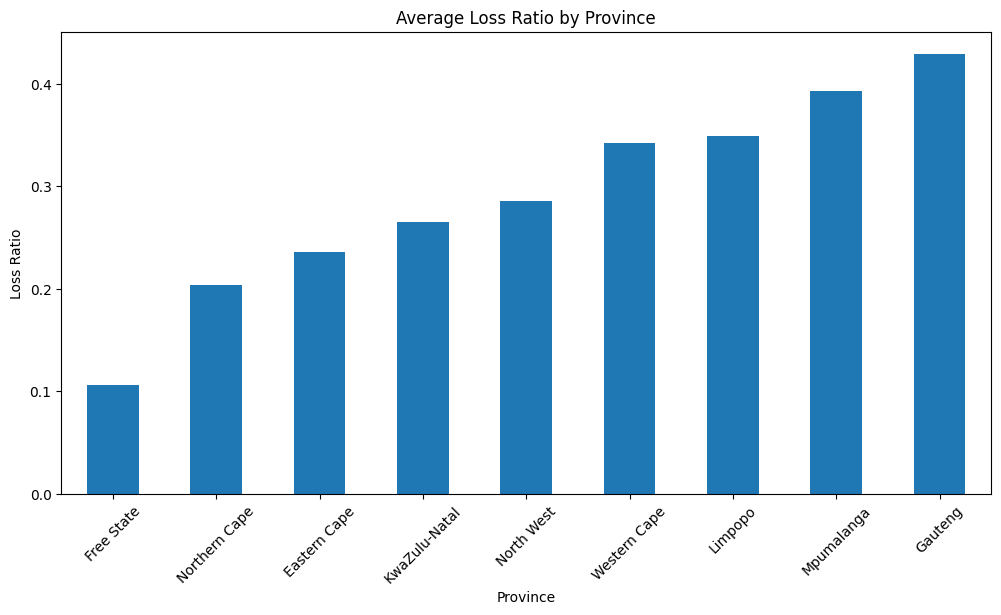

In [12]:
province_risk = df.groupby("Province")["LossRatio"].mean().sort_values()

plt.figure(figsize=(12,6))

province_risk.plot(kind="bar")

plt.title("Average Loss Ratio by Province")
plt.ylabel("Loss Ratio")

plt.xticks(rotation=45)

plt.show()

In [16]:
vehicle_groups = []

for vehicle in df["VehicleType"].dropna().unique():
    group = df[
        df["VehicleType"] == vehicle
    ]["Margin"]

    vehicle_groups.append(group)

In [17]:
vehicle_test = f_oneway(*vehicle_groups)

print("F-statistic:", vehicle_test.statistic)
print("p-value:", vehicle_test.pvalue)

F-statistic: 1.1942635355880842
p-value: 0.31094850683244646


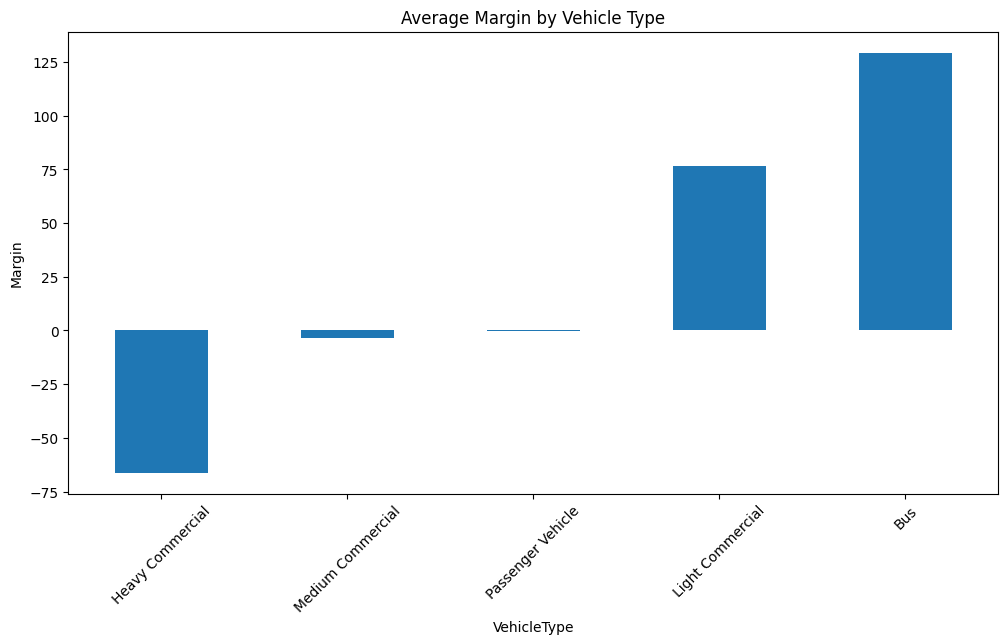

In [18]:
vehicle_margin = df.groupby(
    "VehicleType"
)["Margin"].mean().sort_values()

plt.figure(figsize=(12,6))

vehicle_margin.plot(kind="bar")

plt.title("Average Margin by Vehicle Type")

plt.ylabel("Margin")

plt.xticks(rotation=45)

plt.show()

Final Statistical Summary Table

In [26]:
male_claims = df[df["Gender"] == "Male"]["TotalClaims"]

female_claims = df[df["Gender"] == "Female"]["TotalClaims"]

gender_test = ttest_ind(
    male_claims,
    female_claims,
    nan_policy="omit"
)

print("t-statistic:", gender_test.statistic)
print("p-value:", gender_test.pvalue)

t-statistic: -0.20591741089386628
p-value: 0.8368572892180498


In [28]:
top_postal_codes = (
    df["PostalCode"]
    .value_counts()
    .head(10)
    .index
)

postal_df = df[df["PostalCode"].isin(top_postal_codes)]

In [29]:
postal_groups = []

for code in top_postal_codes:
    group = postal_df[
        postal_df["PostalCode"] == code
    ]["LossRatio"]

    postal_groups.append(group)

In [30]:
postal_anova = f_oneway(*postal_groups)

print("F-statistic:", postal_anova.statistic)
print("p-value:", postal_anova.pvalue)

F-statistic: 2.5687413301097806
p-value: 0.005937255341884647


In [32]:
vehicle_groups = []

for vehicle in df["VehicleType"].dropna().unique():
    group = df[
        df["VehicleType"] == vehicle
    ]["Margin"]

    vehicle_groups.append(group)

In [33]:
vehicle_test = f_oneway(*vehicle_groups)

print("F-statistic:", vehicle_test.statistic)
print("p-value:", vehicle_test.pvalue)

F-statistic: 1.1942635355880842
p-value: 0.31094850683244646


In [34]:
summary = pd.DataFrame({
    "Hypothesis": [
        "Province Risk Difference",
        "Gender Claim Difference",
        "Postal Code Risk Difference",
        "Vehicle Margin Difference"
    ],
    "p-value": [
        anova_result.pvalue,
        gender_test.pvalue,
        postal_anova.pvalue,
        vehicle_test.pvalue
    ]
})

summary["Reject Null?"] = summary["p-value"] < 0.05

summary

,Hypothesis,p-value,Reject Null?
0,Province Risk Difference,0.000004,True
1,Gender Claim Difference,0.836857,False
2,Postal Code Risk Difference,0.005937,True
3,Vehicle Margin Difference,0.310949,False


## Statistical Testing Conclusions

The hypothesis testing phase revealed that geographic variables play a significant role in insurance risk differentiation.

The ANOVA test for provinces produced a statistically significant result (p < 0.05), indicating meaningful differences in Loss Ratio across provinces. Similarly, postal code analysis also showed statistically significant variation in insurance risk.

These findings suggest that geographic segmentation should be incorporated into pricing and underwriting decisions.

However, the gender-based claims analysis did not show statistically significant differences in claim behavior between male and female customers. Likewise, vehicle type alone did not demonstrate a statistically significant impact on profitability margins.

Overall, the results indicate that location-based factors are stronger predictors of insurance risk than demographic variables such as gender.

Province Visualization

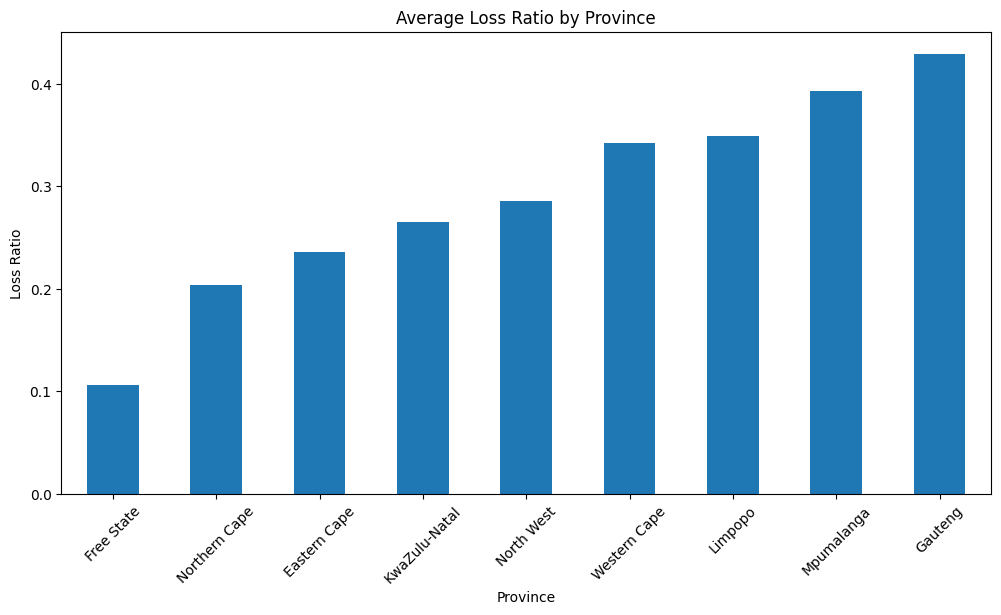

In [35]:
province_risk = df.groupby("Province")["LossRatio"].mean().sort_values()

plt.figure(figsize=(12,6))

province_risk.plot(kind="bar")

plt.title("Average Loss Ratio by Province")
plt.ylabel("Loss Ratio")

plt.xticks(rotation=45)

plt.show()

Gender Visualization

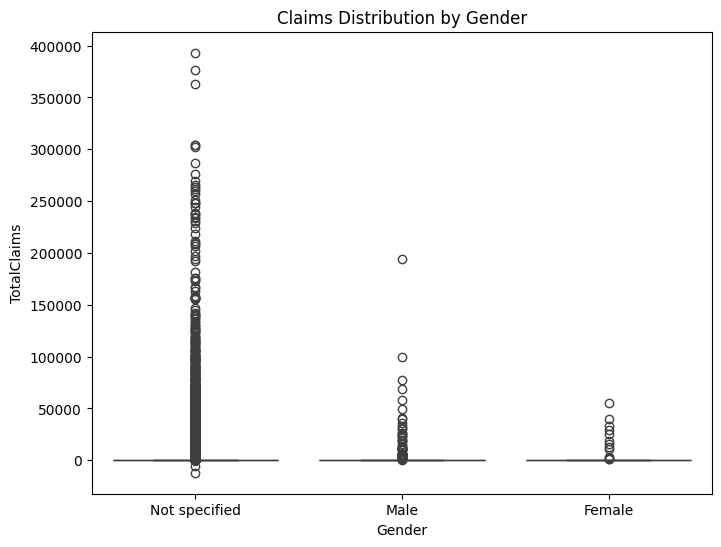

In [36]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Gender",
    y="TotalClaims"
)

plt.title("Claims Distribution by Gender")

plt.show()

Postal Code Visualization

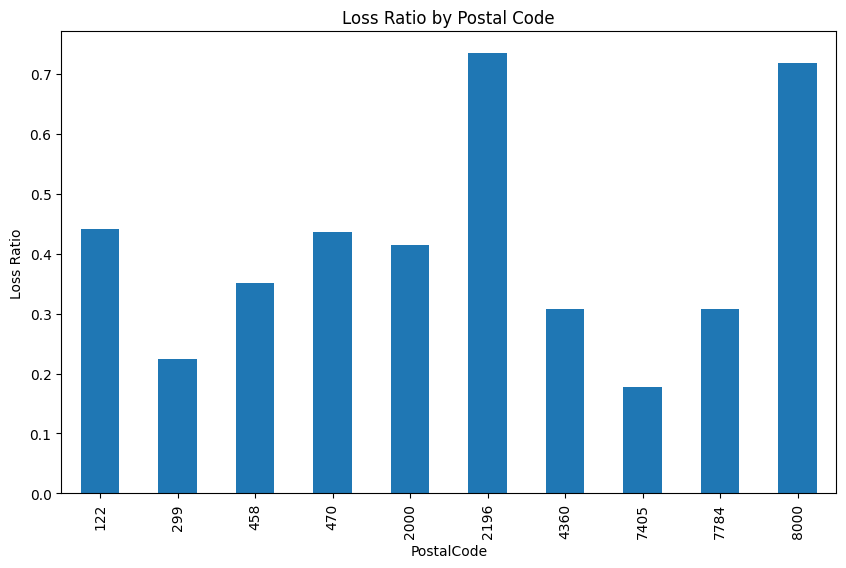

In [37]:
postal_risk = postal_df.groupby(
    "PostalCode"
)["LossRatio"].mean()

plt.figure(figsize=(10,6))

postal_risk.plot(kind="bar")

plt.title("Loss Ratio by Postal Code")

plt.ylabel("Loss Ratio")

plt.show()

Vehicle Margin Visualization

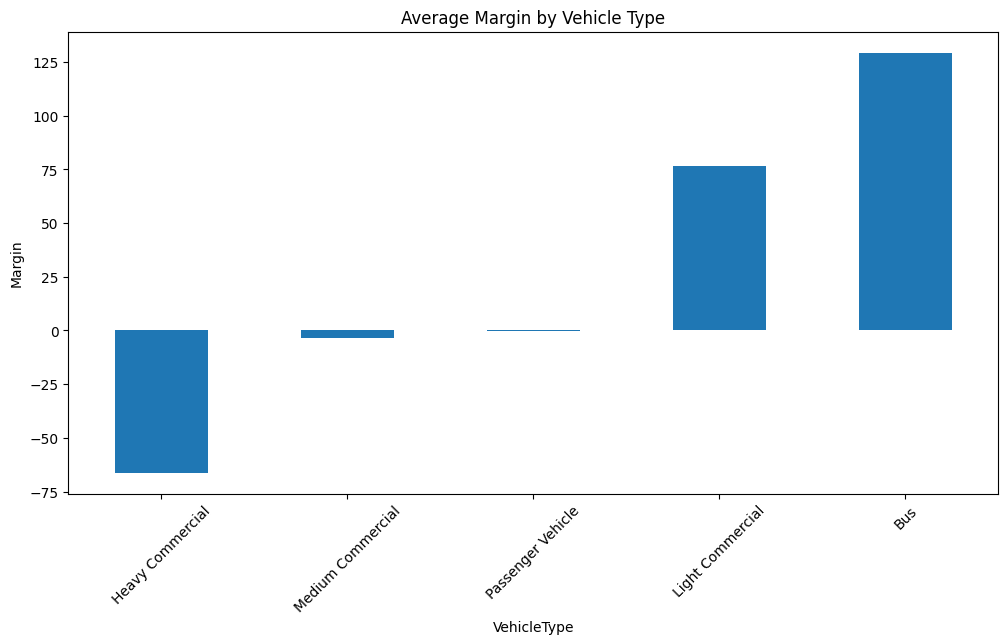

In [38]:
vehicle_margin = df.groupby(
    "VehicleType"
)["Margin"].mean().sort_values()

plt.figure(figsize=(12,6))

vehicle_margin.plot(kind="bar")

plt.title("Average Margin by Vehicle Type")

plt.ylabel("Margin")

plt.xticks(rotation=45)

plt.show()

In [39]:
plt.savefig("../figures/province_loss_ratio.png")

<Figure size 640x480 with 0 Axes>